# Assignment 4 — Linear Regression (Boston Housing)

This notebook builds a linear regression model to predict house prices (`medv`) from the Boston Housing dataset. It includes data loading, basic checks, train/test split, model training, evaluation (MSE, RMSE, R^2), coefficients, and a scatter plot of actual vs predicted values.

In [10]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [11]:
# Load dataset directly from provided train.csv
data = pd.read_csv('train.csv')
print('Loaded from: train.csv')
data.shape

Loaded from: train.csv


(333, 15)

In [12]:
# Quick info and missing values
data.info()
print('\nMissing values per column:')
print(data.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       333 non-null    int64  
 1   crim     333 non-null    float64
 2   zn       333 non-null    float64
 3   indus    333 non-null    float64
 4   chas     333 non-null    int64  
 5   nox      333 non-null    float64
 6   rm       333 non-null    float64
 7   age      333 non-null    float64
 8   dis      333 non-null    float64
 9   rad      333 non-null    int64  
 10  tax      333 non-null    int64  
 11  ptratio  333 non-null    float64
 12  black    333 non-null    float64
 13  lstat    333 non-null    float64
 14  medv     333 non-null    float64
dtypes: float64(11), int64(4)
memory usage: 39.2 KB

Missing values per column:
ID         0
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      

In [13]:
# Detect possible target column names if 'medv' is not present
possible = [c for c in data.columns if c.lower() in ('medv','price','target')]
possible

['medv']

In [14]:
# Train on full training set and predict on provided test.csv
# Prepare features/target from train data
if 'medv' in data.columns:
    target = 'medv'
else:
    raise KeyError('Target column (medv) not found in training data')
# Drop ID from features if present
features = [c for c in data.columns if c not in ('ID', target)]
X = data[features]
y = data[target]
# Load test set
test_df = pd.read_csv('test.csv')
test_ids = test_df['ID'] if 'ID' in test_df.columns else None
X_test_external = test_df[features]
# Train on full training data
model = LinearRegression()
model.fit(X, y)
print('Trained on:', X.shape)
print('Predicting on test set:', X_test_external.shape)
print('Intercept:', model.intercept_)
coefficients = pd.DataFrame(model.coef_, features, columns=['Coefficient'])
coefficients

Trained on: (333, 13)
Predicting on test set: (173, 13)
Intercept: 34.04543776350591


,Coefficient
crim,-0.052489
zn,0.047445
indus,0.053855
chas,3.784864
nox,-15.739657
rm,3.768832
age,-0.004627
dis,-1.548823
rad,0.328967
tax,-0.012866


Validation MSE: 20.04579638341932
Validation RMSE: 4.477253218595004
Validation R^2: 0.7462055149257579


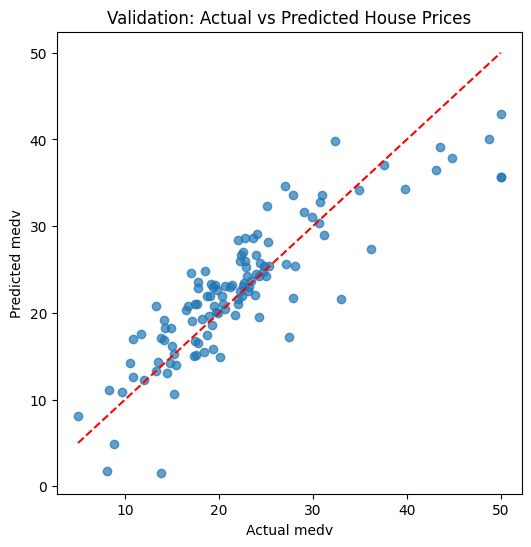

In [ ]:
# Evaluate model performance using an internal train/validation split
X_train_eval, X_val, y_train_eval, y_val = train_test_split(X, y, test_size=0.35, random_state=42)
model_eval = LinearRegression()
model_eval.fit(X_train_eval, y_train_eval)
y_val_pred = model_eval.predict(X_val)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_val, y_val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_val_pred)
print('Validation MSE:', mse)
print('Validation RMSE:', rmse)
print('Validation R^2:', r2)
# Scatter plot actual vs predicted on the validation set
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_val_pred, alpha=0.7)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Actual medv')
plt.ylabel('Predicted medv')
plt.title('Validation: Actual vs Predicted House Prices')
plt.show()